# 1. Introduction
Welcome! We are trying to predict Autism traits using simple Machine Learning.

**Why we do this:** This is for our college project. We want to show we can build a working ML model.


## 2. Importing libraries 


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, accuracy_score, precision_score, recall_score


import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')


## 3. Data Loading 



In [28]:
df = pd.read_csv('Dataset.csv')
print('Dataset Shape:', df.shape)
display(df.head())


Dataset Shape: (800, 22)


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


## 4. Data Cleaning

###  Fixing Text and Removing outliers 


**Why we do this:** 
- ML models only understand numbers (1 and 0), not words.
- Extreme negative test results are errors and will make our model bad.


In [29]:
print("Ethnicity:", df['ethnicity'].unique())
print("-----------------------------------------------------------")
print("Relation:", df['relation'].unique())
print("-----------------------------------------------------------")
print("Jaundice:", df['jaundice'].unique())
print("-----------------------------------------------------------")
print("Used App Before:", df['used_app_before'].unique())

Ethnicity: ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
-----------------------------------------------------------
Relation: ['Self' 'Relative' 'Parent' '?' 'Others' 'Health care professional']
-----------------------------------------------------------
Jaundice: ['no' 'yes']
-----------------------------------------------------------
Used App Before: ['no' 'yes']


In [30]:


df = df.replace({'yes': 1, 'no': 0, '?': 'Others', 'others': 'Others'})
''' Removing outlier from result '''
df = df[df['result'] > -5]

print('Total rows after cleaning:', df.shape[0])


Total rows after cleaning: 798


### 4.2 Grouping Countries


*Having 56 different countries will create too many columns later. Keeping it simple helps the model run better.


In [31]:
counts = df['contry_of_res'].value_counts()

df['contry_of_res'] = df['contry_of_res'].where(df['contry_of_res'].map(counts) >= 10, 'Other')

print(df['contry_of_res'].value_counts())


contry_of_res
United States           134
Other                   132
India                   107
New Zealand              78
United Kingdom           67
Jordan                   54
United Arab Emirates     40
Australia                37
Canada                   30
Afghanistan              22
Netherlands              20
Austria                  18
Sri Lanka                17
Brazil                   12
France                   10
Kazakhstan               10
Spain                    10
Name: count, dtype: int64


## 5. Exploratory Data Analysis (EDA)


Let's see the total counts of people with and without Autism (our Target Variable), and also age and test results.

 To see if our dataset is balanced or if one group has way more people than the other.


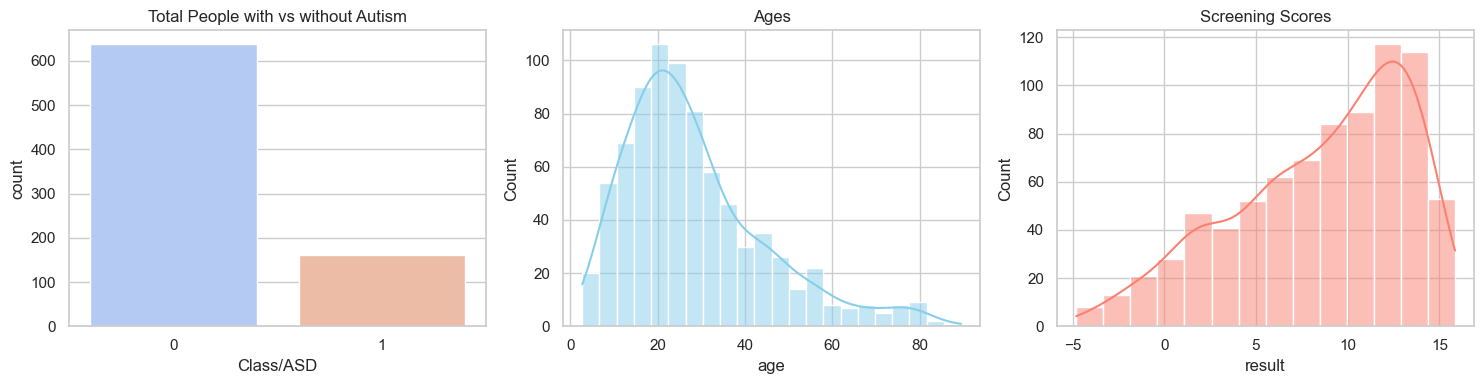

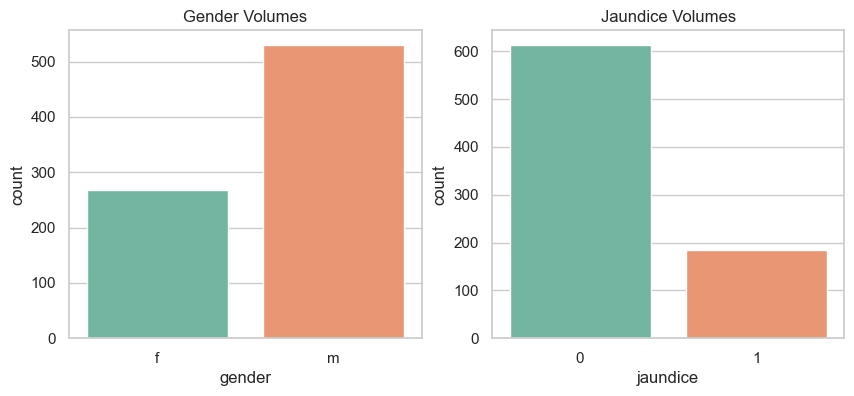

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='Class/ASD', palette='coolwarm', ax=ax[0])
ax[0].set_title('Total People with vs without Autism')

sns.histplot(df['age'], kde=True, ax=ax[1], color='skyblue')
ax[1].set_title('Ages')

sns.histplot(df['result'], kde=True, ax=ax[2], color='salmon')
ax[2].set_title('Screening Scores')

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(data=df, x='gender', ax=ax2[0], palette='Set2')
ax2[0].set_title('Gender Volumes')

sns.countplot(data=df, x='jaundice', ax=ax2[1], palette='Set2')
ax2[1].set_title('Jaundice Volumes')
plt.show()


### 5.2 Comparing Features to Target
Let's see how our target (Class/ASD) compares to other columns like age, gender, and jaundice. We will also check the Mean Autism Rate.

**Why we do this:** To see if specific things like Jaundice or Ethnicity have higher chances of leading to Autism.


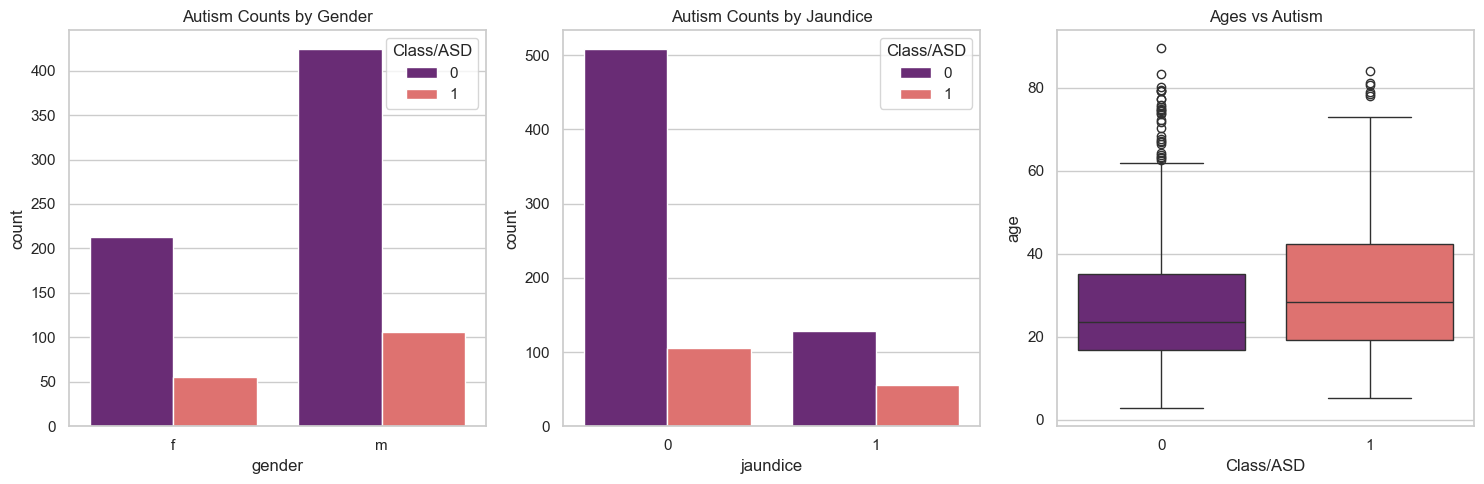

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(data=df, x='gender', hue='Class/ASD', palette='magma', ax=ax[0])
ax[0].set_title('Autism Counts by Gender')

sns.countplot(data=df, x='jaundice', hue='Class/ASD', palette='magma', ax=ax[1])
ax[1].set_title('Autism Counts by Jaundice')

sns.boxplot(data=df, x='Class/ASD', y='age', palette='magma', ax=ax[2])
ax[2].set_title('Ages vs Autism')

plt.tight_layout()
plt.show()


###  Mean Autism Rate Plots
Here we check the average chance (rate) of Autism grouped by Ethnicity, Gender, Jaundice, and Relation.
These bar plots show exactly which groups have a higher percentage of the diagnosis.


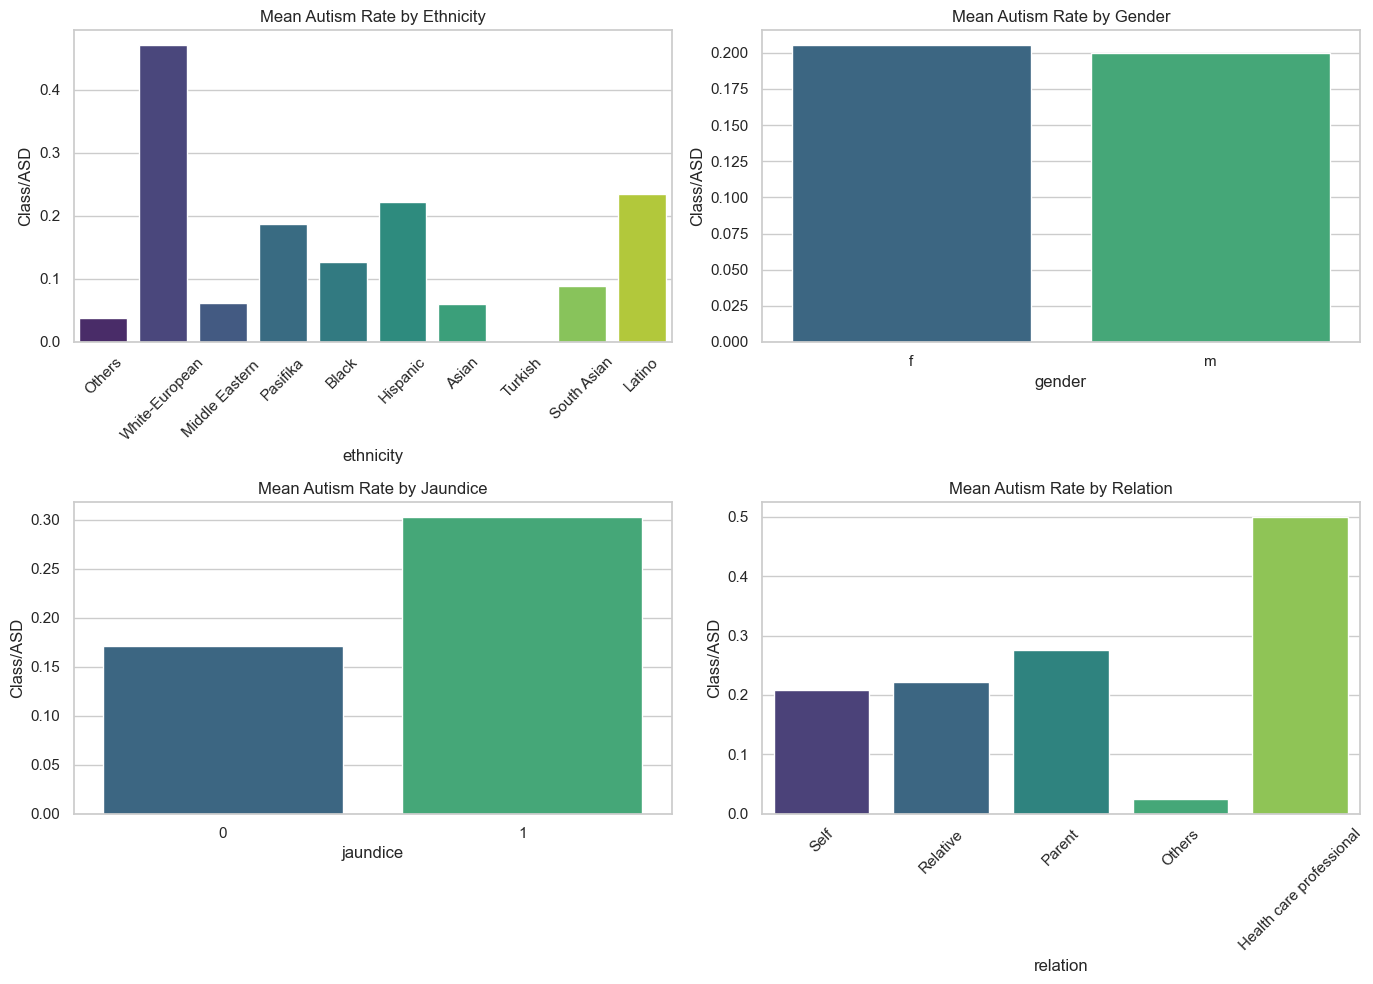

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df, x='ethnicity', y='Class/ASD', errorbar=None, ax=ax[0,0], palette='viridis')
ax[0,0].set_title('Mean Autism Rate by Ethnicity')
ax[0,0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='gender', y='Class/ASD', errorbar=None, ax=ax[0,1], palette='viridis')
ax[0,1].set_title('Mean Autism Rate by Gender')

sns.barplot(data=df, x='jaundice', y='Class/ASD', errorbar=None, ax=ax[1,0], palette='viridis')
ax[1,0].set_title('Mean Autism Rate by Jaundice')

sns.barplot(data=df, x='relation', y='Class/ASD', errorbar=None, ax=ax[1,1], palette='viridis')
ax[1,1].set_title('Mean Autism Rate by Relation')
ax[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 6. Splitting the Data
First, we drop the 'result' column and ID. Then we divide the data into Training (70%), Validation (15%), and Test (15%).


- We drop 'result' because knowing the test score makes the model cheat.
- We divide data so the model can train on 70%, be checked on 15%, and finally tested on a totally new 15% for final evaluation


In [35]:

y = df['Class/ASD']


cols_to_removed = ['ID', 'result','Class/ASD', 'austim', 'age_desc']
X = df.drop(cols_to_removed,axis=1)


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training blocks: {X_train.shape} inputs (70%)")
print(f"Validation verification blocks: {X_val.shape} inputs (15%)")
print(f"Final testing blocks: {X_test.shape} inputs (15%)")


Training blocks: (558, 17) inputs (70%)
Validation verification blocks: (120, 17) inputs (15%)
Final testing blocks: (120, 17) inputs (15%)


## 7. Scaling and Encoding of categorical variables 
We use StandardScaler and OneHotEncoder here.




In [36]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)


(558, 43)
(120, 43)
(120, 43)


## 8. Baseline  ML Models
We train Logistic Regression, Decision Tree, and Random Forest  and Xg boost using balanced class weights.

 We use balanced weights so the model doesn't just ignore the smaller group.


In [37]:


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'LogisticRegression': LogisticRegression(random_state=42, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss')
}

results = []



for name, model in models.items():
    model.fit(X_train_processed, y_train)
    
    preds = model.predict(X_val_processed)
    proba = model.predict_proba(X_val_processed)[:, 1]
    
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds)
    rec = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    roc = roc_auc_score(y_val, proba)
    
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc
    })

val_df = pd.DataFrame(results)
print(val_df)


                Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  LogisticRegression  0.808333   0.512821  0.833333  0.634921  0.878038
1        DecisionTree  0.791667   0.483871  0.625000  0.545455  0.729167
2        RandomForest  0.833333   0.590909  0.541667  0.565217  0.871745
3             XGBoost  0.841667   0.586207  0.708333  0.641509  0.844618


## 9. Handling Imbalance (SMOTE)
We use SMOTE to create fake data for the smaller group. Then we do Cross Validation.

 
- SMOTE makes both groups exactly equal in size.
- Cross Validation tests the model 5 times on different parts of the data. This proves the model didn't just memorize the data.


Before SMOTE:

Class/ASD
0    445
1    113
Name: count, dtype: int64


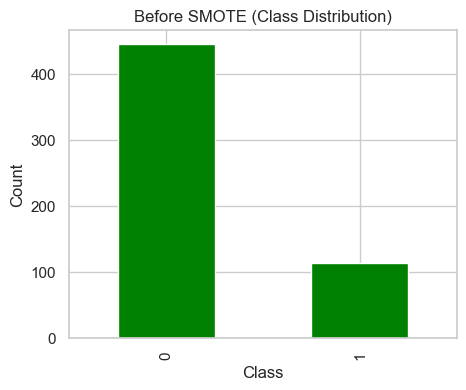


After SMOTE:

Class/ASD
0    445
1    445
Name: count, dtype: int64


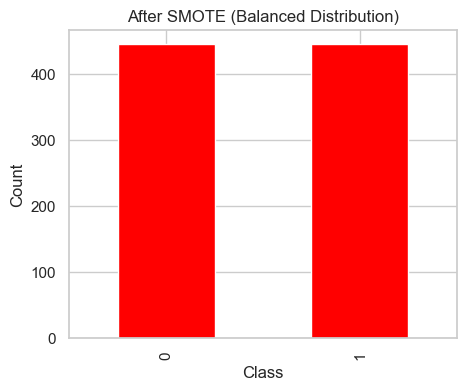

In [38]:

print("Before SMOTE:\n")
print(y_train.value_counts())


plt.figure(figsize=(5,4))
y_train.value_counts().plot(kind='bar',color='green')
plt.title("Before SMOTE (Class Distribution)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_processed, y_train)


print("\nAfter SMOTE:\n")
print(y_smote.value_counts())


plt.figure(figsize=(5,4))
y_smote.value_counts().plot(kind='bar',color='red')
plt.title("After SMOTE (Balanced Distribution)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [39]:

models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss')

}

results = []



for name, model in models.items():
    model.fit(X_smote, y_smote)
    
    preds = model.predict(X_val_processed)
    proba = model.predict_proba(X_val_processed)[:, 1]
    
    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds)
    rec = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)
    roc = roc_auc_score(y_val, proba)
    
 
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc
    })

val_df = pd.DataFrame(results)
print( val_df)


                Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  LogisticRegression  0.833333   0.552632  0.875000  0.677419  0.896701
1        DecisionTree  0.741667   0.370370  0.416667  0.392157  0.619792
2        RandomForest  0.841667   0.600000  0.625000  0.612245  0.865234
3             XGBoost  0.833333   0.566667  0.708333  0.629630  0.845920


## 10. Final Test
We test our best model (Logistic Regression) on the final 15% unseen test data.

Checking the model on completely new data proves it will work in the real world.


--- Final Test Results ---

              precision    recall  f1-score   support

           0       0.94      0.81      0.87        96
           1       0.51      0.79      0.62        24

    accuracy                           0.81       120
   macro avg       0.73      0.80      0.75       120
weighted avg       0.85      0.81      0.82       120



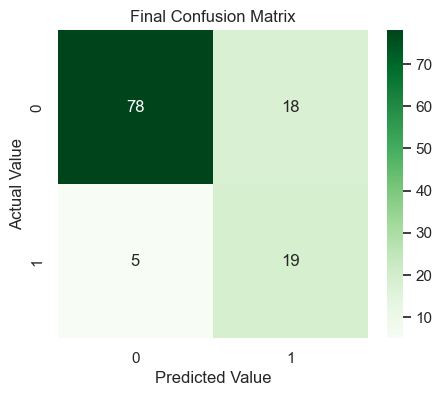

In [42]:
best_model = LogisticRegression(random_state=42)
best_model.fit(X_smote, y_smote)

test_preds = best_model.predict(X_test_processed)

print("--- Final Test Results ---\n")
print(classification_report(y_test, test_preds))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Final Confusion Matrix')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()


## 11. Model Exporting
We will now save our trained models and preprocessors so they can be loaded strictly by an external Application (like Streamlit UI).
 Saving (Pickling/Joblib) the model allows us to ship and deploy it into the real world securely without having to retrain the math engine from scratch every time.

In [43]:
import joblib


joblib.dump(preprocessor, 'preprocessor.joblib')
joblib.dump(best_model, 'best_model.joblib')


print("Models securely exported to disk for Deployment!")


Models securely exported to disk for Deployment!
